In [27]:
# Import modules I made need
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
from matplotlib.lines import Line2D

from shapely.geometry import Point, Polygon as ShapelyPolygon
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import matplotlib.ticker as ticker

import seaborn as sns
from shapely.geometry import Point, Polygon as ShapelyPolygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import imageio

import cmocean
import cmocean.cm as cmo
import importlib
import utils  # Importing the utils module


import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

from matplotlib.colors import LinearSegmentedColormap

In [28]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
output_path = repo_path + 'processed_data/'
fig_path = repo_path + 'figures/'

#Files
start_file = 'IDLloc_spawning_21dfilter.csv'

starting_location_df=pd.read_csv(output_path + start_file) 

In [29]:

# List of simulations and locations
locations = ['BS', 'GERL', 'GP', 'MB2']

file = output_path + 'processed_trajectories_21dfilter.csv'

processed_df=pd.read_csv(file) 
print('raw number of larvae:', processed_df.larval_id.nunique())
df = processed_df.copy()

raw number of larvae: 11487


In [30]:
df.columns

Index(['N', 'T', 'date', 'lat', 'lon', 'release', 'stage', 'larval_id',
       'start_year', 'hypothesis', 'IDL_loc', 'BS', 'GERL', 'GP', 'MB2',
       'outside'],
      dtype='object')

In [31]:
# Merge definitive IDL_loc assignments from starting_location_df
merged_df = pd.merge(
    df,
    starting_location_df[['larval_id', 'hypothesis', 'start_year', 'IDL_loc']],
    on=['larval_id', 'hypothesis', 'start_year'],
    how='inner',  # retain only larvae that met the 21-day criterion
    suffixes=('', '_assigned')
)

# Overwrite IDL_loc with the assignment from starting_location_df
merged_df['IDL_loc'] = merged_df['IDL_loc_assigned']
merged_df = merged_df.drop(columns=['IDL_loc_assigned'])

print('✅ Merged with definitive nursery assignments. Larvae retained:', merged_df.larval_id.nunique())

✅ Merged with definitive nursery assignments. Larvae retained: 11487


In [32]:
def summarize_larvae_by_nursery(df, hypothesis):
    """
    Print a quick summary of larval counts per nursery and year for a given hypothesis.
    """
    subset = df[df['hypothesis'] == hypothesis]
    summary = (
        subset.groupby(['IDL_loc', 'start_year'])['larval_id']
        .nunique()
        .reset_index(name='n_larvae')
        .sort_values(['IDL_loc', 'start_year'])
    )
    print(f"🔎 Larval counts for hypothesis '{hypothesis}':\n")
    print(summary.to_string(index=False))
    return summary

In [33]:
summary_620 = summarize_larvae_by_nursery(merged_df, 'h_dvm')
summary_640 = summarize_larvae_by_nursery(merged_df, 'h_size')

🔎 Larval counts for hypothesis 'h_dvm':

IDL_loc  start_year  n_larvae
     BS        2016       290
     BS        2017       184
     BS        2018       237
   GERL        2016        45
   GERL        2017        29
   GERL        2018        32
     GP        2016        66
     GP        2017        28
     GP        2018        22
    MB2        2016        60
    MB2        2017        71
    MB2        2018        36
🔎 Larval counts for hypothesis 'h_size':

IDL_loc  start_year  n_larvae
     BS        2016       891
     BS        2017       710
     BS        2018       899
   GERL        2016       310
   GERL        2017       269
   GERL        2018       318
     GP        2016      1063
     GP        2017       862
     GP        2018       761
    MB2        2016      1002
    MB2        2017       942
    MB2        2018       935


In [34]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need

# Import necessary data and functions from utils
hypotheses = utils.hypotheses
stages = utils.stages
locations = utils.locations
start_years = utils.start_years
months_data = utils.months_data
extents = utils.extents
bathymetry = utils.bathymetry

# function
plot_region = utils.plot_region
plot_contour = utils.plot_contour

In [35]:
importlib.reload(utils) # Run this if you update something in your utils file you need

boxes = {key: value['boxes'] for key, value in locations.items()}
location_labels = {key: value['name'] for key, value in locations.items()}
location_colors = {key: value['color'] for key, value in locations.items()}
location_order = {key: value['order'] for key, value in locations.items()}

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

start_years = utils.start_years
start_years_colors = {key: value['color'] for key, value in start_years.items()}

extent = [-76, -46, -71, -58]
nursery_info = locations
print(nursery_info)

{'BS': {'name': 'BS', 'label_short': 'Bransf.', 'label': 'Bransfeild Strait', 'ng': 'BS-NG', 'order': 0, 'color': '#d55e00', 'boxes': [{'lonpoly': [302, 300, 300, 298, 298, 300, 300, 302, 302], 'latpoly': [-62.5, -62.5, -62.6, -62.6, -63.7, -63.7, -63.5, -63.5, -62.5]}]}, 'GERL': {'name': 'GS', 'label_short': 'Gerl.', 'label': 'Gerlache Strait', 'ng': 'BS-NG', 'order': 1, 'color': '#029e73', 'boxes': [{'lonpoly': [296.1, 298.5, 299.6, 297.6], 'latpoly': [-64.7, -63.6, -64.0, -65.3]}]}, 'GP': {'name': 'GP', 'label_short': 'Grand.', 'label': 'Grandidier Passage', 'ng': 'GP-NG', 'order': 2, 'color': '#cc78bc', 'boxes': [{'lonpoly': [291.6, 295.5, 297.6, 294.0], 'latpoly': [-66.7, -64.5, -65.3, -67.4]}]}, 'MB2': {'name': 'MB', 'label_short': 'M. Bay', 'label': 'Marguerite Bay', 'ng': 'MB-NG', 'order': 3, 'color': '#0173b2', 'boxes': [{'lonpoly': [287.7, 290.5, 294.0, 292.0], 'latpoly': [-69.1, -67.5, -68.5, -69.7]}]}}


## Functions to Process Data

Function add_transition_columns
•	For each location:
	•	Adds a prev column with the previous timestep’s presence (True/False).
	•	Assigns a transition string (initial_inside, immigrate, emigrate, inside, outside) using a helper

In [36]:
def add_transition_columns(df, locations):
    """
    Add transition and origin classification columns for each nursery location.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with boolean nursery columns (e.g., ['BS', 'GERL']).
        locations (list): List of nursery location keys (e.g., ['BS', 'GERL', 'GP', 'MB2']).
    
    Returns:
        pd.DataFrame: Updated DataFrame with transition and origin info.
    """
    def categorize_transition(prev, curr):
        if pd.isna(prev):
            return 'initial_inside' if curr else 'initial_outside'
        if not prev and curr:
            return 'immigrate'
        elif prev and not curr:
            return 'emigrate'
        elif prev and curr:
            return 'inside'
        else:
            return 'outside'

    for loc in locations:
        prev_col = f'{loc}_prev'
        trans_col = f'{loc}_transition'
        origin_col = f'{loc}_origin'

        # Step 1: Add previous-state and transition column
        df[prev_col] = df.groupby('larval_id')[loc].shift(1)
        df[trans_col] = [categorize_transition(p, c) for p, c in zip(df[prev_col], df[loc])]

        # Step 2: Determine origin (Local vs Immigrant) at larval level
        # Get larval_ids with 'initial_inside' at this location
        local_ids = (
            df[df[trans_col] == 'initial_inside']
            .groupby('larval_id')
            .size()
            .index
        )
        
        # Map back to DataFrame
        df[origin_col] = df['larval_id'].apply(lambda x: 'Local' if x in local_ids else 'Immigrant')

    return df

# Add transition columns to the dataframe
df = add_transition_columns(merged_df, locations)
print(df.head())

   N  T        date        lat        lon  release  stage     larval_id  \
0  2  0  2016-11-01 -63.602314  298.26752        0      0  00_16_1_0003   
1  2  1  2016-11-02 -63.569042  298.23145        0      0  00_16_1_0003   
2  2  2  2016-11-03 -63.522503  298.25543        0      0  00_16_1_0003   
3  2  3  2016-11-04 -63.483067  298.28790        0      0  00_16_1_0003   
4  2  4  2016-11-05 -63.438553  298.33795        0      0  00_16_1_0003   

   start_year hypothesis  ... BS_origin  GERL_prev  GERL_transition  \
0        2016     h_null  ...     Local        NaN  initial_outside   
1        2016     h_null  ...     Local      False          outside   
2        2016     h_null  ...     Local      False          outside   
3        2016     h_null  ...     Local      False          outside   
4        2016     h_null  ...     Local      False          outside   

   GERL_origin  GP_prev    GP_transition  GP_origin MB2_prev   MB2_transition  \
0    Immigrant      NaN  initial_outside 

In [37]:
def gut_check_nursery_origin_counts(df, nurseries, hypothesis):
    """
    Validate larval counts per nursery and year by origin type.

    Returns a DataFrame showing:
    - total larvae that used the nursery
    - number of locals
    - number of immigrants
    - whether local + immigrant == total
    - hypothesis name
    """
    records = []
    df_hyp = df[df['hypothesis'] == hypothesis]

    for nursery in nurseries:
        origin_col = f"{nursery}_origin"

        # Only include larvae assigned to this nursery
        df_ng = df_hyp[df_hyp['IDL_loc'] == nursery]

        for year in sorted(df_ng['start_year'].unique()):
            df_year = df_ng[df_ng['start_year'] == year]

            # Drop duplicates to avoid inflating counts
            df_year_unique = df_year.drop_duplicates(subset='larval_id')

            local_ids = df_year_unique[df_year_unique[origin_col] == 'Local']['larval_id']
            immigrant_ids = df_year_unique[df_year_unique[origin_col] == 'Immigrant']['larval_id']

            total = len(df_year_unique)
            locals_ = len(local_ids)
            immigrants = len(immigrant_ids)
            match = (locals_ + immigrants == total)

            records.append({
                'hypothesis': hypothesis,
                'nursery': nursery,
                'start_year': year,
                'total_larvae': total,
                'spawn_local': locals_,
                'spawn_external': immigrants,
                'match': match
            })

    return pd.DataFrame(records)

In [38]:
# Run gut check for both hypotheses
summary_dvm = gut_check_nursery_origin_counts(df, nurseries=['BS', 'GERL', 'GP', 'MB2'], hypothesis='h_dvm')
summary_size = gut_check_nursery_origin_counts(df, nurseries=['BS', 'GERL', 'GP', 'MB2'], hypothesis='h_size')

# Add percent_inhouse to each
summary_dvm['percent_inhouse'] = (summary_dvm['spawn_local'] / summary_dvm['total_larvae'] * 100).round(1)
summary_size['percent_inhouse'] = (summary_size['spawn_local'] / summary_size['total_larvae'] * 100).round(1)

# Combine both into one DataFrame
summary_combined = pd.concat([summary_dvm, summary_size], ignore_index=True)

# Optional: Subset for BS and MB2 only
summary_subset = summary_combined[summary_combined['nursery'].isin(['BS', 'MB2'])]

# Display result
summary_combined

,hypothesis,nursery,start_year,total_larvae,spawn_local,spawn_external,match,percent_inhouse
0,h_dvm,BS,2016,290,128,162,True,44.1
1,h_dvm,BS,2017,184,123,61,True,66.8
2,h_dvm,BS,2018,237,120,117,True,50.6
3,h_dvm,GERL,2016,45,0,45,True,0.0
4,h_dvm,GERL,2017,29,0,29,True,0.0
5,h_dvm,GERL,2018,32,0,32,True,0.0
6,h_dvm,GP,2016,66,0,66,True,0.0
7,h_dvm,GP,2017,28,0,28,True,0.0
8,h_dvm,GP,2018,22,0,22,True,0.0
9,h_dvm,MB2,2016,60,38,22,True,63.3


In [41]:
def gut_check_nursery_origin_3year_avg(df, nurseries, hypotheses):
    """
    Returns a 3-year averaged version of the origin summary:
    - Summed larvae counts across 2016–2018 per nursery and hypothesis.
    """
    records = []

    for hypothesis in hypotheses:
        df_hyp = df[df['hypothesis'] == hypothesis]

        for nursery in nurseries:
            origin_col = f"{nursery}_origin"

            # Only include larvae assigned to this nursery
            df_ng = df_hyp[df_hyp['IDL_loc'] == nursery]

            # Drop duplicate larval IDs to ensure unique counting
            df_unique = df_ng.drop_duplicates(subset='larval_id')

            local_ids = df_unique[df_unique[origin_col] == 'Local']['larval_id']
            immigrant_ids = df_unique[df_unique[origin_col] == 'Immigrant']['larval_id']

            n_total = len(df_unique)
            n_local = len(local_ids)
            n_external = len(immigrant_ids)
            match = (n_local + n_external == n_total)
            percent_inhouse = (n_local / n_total * 100) if n_total > 0 else 0.0

            records.append({
                'hypothesis': hypothesis,
                'nursery': nursery,
                'n_total': n_total,
                'spawn_local': n_local,
                'spawn_external': n_external,
                'percent_inhouse': round(percent_inhouse, 1),
                'match': match
            })

    return pd.DataFrame(records)

In [43]:
summary_avg = gut_check_nursery_origin_3year_avg(
    df=merged_df,
    nurseries=['BS', 'GERL', 'GP', 'MB2'],
    hypotheses=['h_dvm', 'h_size']
)
summary_avg

,hypothesis,nursery,n_total,spawn_local,spawn_external,percent_inhouse,match
0,h_dvm,BS,711,371,340,52.2,True
1,h_dvm,GERL,106,0,106,0.0,True
2,h_dvm,GP,116,0,116,0.0,True
3,h_dvm,MB2,167,103,64,61.7,True
4,h_size,BS,2500,858,1642,34.3,True
5,h_size,GERL,897,231,666,25.8,True
6,h_size,GP,2686,891,1795,33.2,True
7,h_size,MB2,2879,990,1889,34.4,True


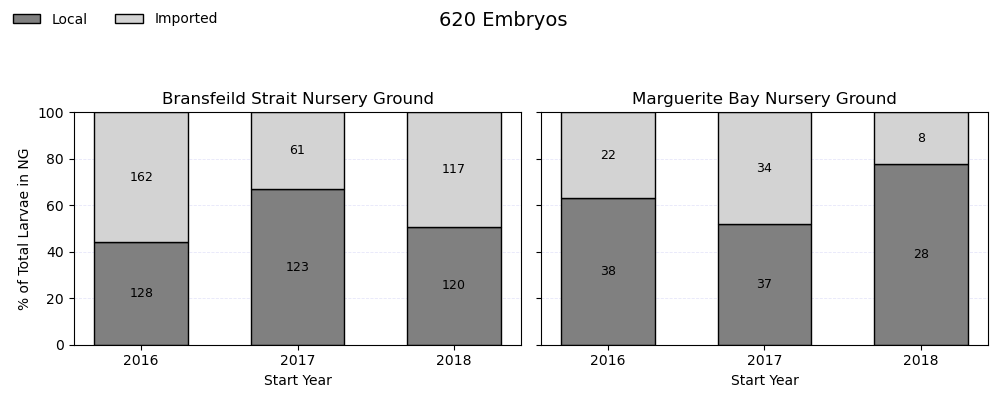

In [39]:
# Filter and compute % imported
df_plot = summary_combined[
    (summary_combined['hypothesis'] == 'h_dvm') &
    (summary_combined['nursery'].isin(['BS', 'MB2']))
].copy()

df_plot['percent_imported'] = (df_plot['spawn_external'] / df_plot['total_larvae'] * 100).round(1)

# Settings
nurseries = ['BS', 'MB2']
years = [2016, 2017, 2018]
bar_width = 0.6
fig, axes = plt.subplots(1, len(nurseries), figsize=(10, 4), sharey=True)

for ax, nursery in zip(axes, nurseries):
    df_n = df_plot[df_plot['nursery'] == nursery].sort_values('start_year')

    x = range(len(years))
    local = df_n['percent_inhouse'].values
    imported = df_n['percent_imported'].values
    local_counts = df_n['spawn_local'].values
    imported_counts = df_n['spawn_external'].values
    ax.set_axisbelow(True)
    # Stacked bars
    bars1 = ax.bar(x, local, bar_width,
                   label='Local', color='gray', edgecolor='black')
    bars2 = ax.bar(x, imported, bar_width,
                   bottom=local, label='Imported', color='lightgray', edgecolor='black')

    # Annotations for each section
    for i in range(len(x)):
        ax.text(x[i], local[i]/2, str(int(local_counts[i])),
                ha='center', va='center', fontsize=9, color='black')
        ax.text(x[i], local[i] + imported[i]/2, str(int(imported_counts[i])),
                ha='center', va='center', fontsize=9, color='black')

    # Axes formatting
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    ax.set_title(f"{nursery_info[nursery]['label']} Nursery Ground")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Start Year")
    ax.grid(axis='y', which='major', linestyle='--', linewidth=0.6, color='lavender')
    if ax == axes[0]:
        ax.set_ylabel("% of Total Larvae in NG")

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, frameon=False)

fig.suptitle("620 Embryos", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

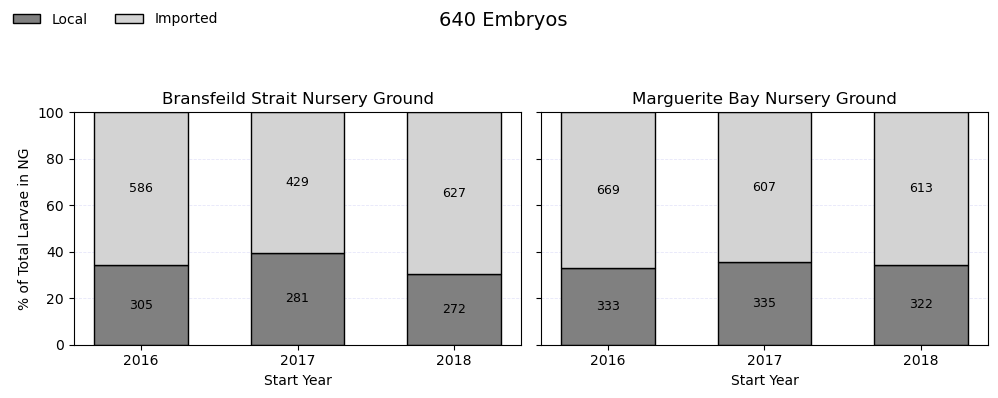

In [40]:

# Filter and compute % imported
df_plot = summary_combined[
    (summary_combined['hypothesis'] == 'h_size') &
    (summary_combined['nursery'].isin(['BS', 'MB2']))
].copy()

df_plot['percent_imported'] = (df_plot['spawn_external'] / df_plot['total_larvae'] * 100).round(1)

# Settings
nurseries = ['BS', 'MB2']
years = [2016, 2017, 2018]
bar_width = 0.6
fig, axes = plt.subplots(1, len(nurseries), figsize=(10, 4), sharey=True)

for ax, nursery in zip(axes, nurseries):
    df_n = df_plot[df_plot['nursery'] == nursery].sort_values('start_year')

    x = range(len(years))
    local = df_n['percent_inhouse'].values
    imported = df_n['percent_imported'].values
    local_counts = df_n['spawn_local'].values
    imported_counts = df_n['spawn_external'].values
    ax.set_axisbelow(True)
    # Stacked bars
    bars1 = ax.bar(x, local, bar_width,
                   label='Local', color='gray', edgecolor='black')
    bars2 = ax.bar(x, imported, bar_width,
                   bottom=local, label='Imported', color='lightgray', edgecolor='black')

    # Annotations for each section
    for i in range(len(x)):
        ax.text(x[i], local[i]/2, str(int(local_counts[i])),
                ha='center', va='center', fontsize=9, color='black')
        ax.text(x[i], local[i] + imported[i]/2, str(int(imported_counts[i])),
                ha='center', va='center', fontsize=9, color='black')

    # Axes formatting
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    ax.set_title(f"{nursery_info[nursery]['label']} Nursery Ground")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Start Year")
    ax.grid(axis='y', which='major', linestyle='--', linewidth=0.6, color='lavender')
    if ax == axes[0]:
        ax.set_ylabel("% of Total Larvae in NG")
# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, frameon=False)

fig.suptitle("640 Embryos", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

# NO FILTER


In [44]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
output_path = repo_path + 'processed_data/'
fig_path = repo_path + 'figures/'


In [45]:

# List of simulations and locations
locations = ['BS', 'GERL', 'GP', 'MB2']

file = output_path + 'processed_trajectories_wpresence_unfiltered.csv'

processed_df=pd.read_csv(file) 
print('raw number of larvae:', processed_df.larval_id.nunique())
df = processed_df.copy()

raw number of larvae: 16658


In [46]:
# Extract Summary Information
critical_columns = ['larval_id', 'date', 'lon', 'lat', 'hypothesis', 'start_year', 'IDL_loc', 'stage']
presence_columns = ['BS', 'GERL', 'GP', 'MB2','outside']

# Function to create the starting location DataFrame
def create_starting_location_df(df):
    t0_data = df[df['T'] == 0].copy()
    starting_locations = t0_data[critical_columns+presence_columns].copy()  # Use copy() to avoid SettingWithCopyWarning
    starting_locations.rename(columns={'date': 'release_date', 'lat': 'release_lat', 'lon': 'release_lon'}, inplace=True)
    return starting_locations

# Create the starting location DataFrame
starting_location_df = create_starting_location_df(processed_df)

# Check It
print('number of larvae:', starting_location_df.larval_id.nunique())
# presence_summary_starting_location = summarize_presence(starting_location_df)
starting_location_df.head()

number of larvae: 16658


,larval_id,release_date,release_lon,release_lat,hypothesis,start_year,IDL_loc,stage,BS,GERL,GP,MB2,outside
0,00_16_1_0001,2016-11-01,287.83374,-66.912544,h_null,2016,BS,0,False,False,False,False,True
180,00_16_1_0002,2016-11-01,292.12890,-64.621430,h_null,2016,BS,0,False,False,False,False,True
360,00_16_1_0003,2016-11-01,298.26752,-63.602314,h_null,2016,BS,0,True,False,False,False,False
540,00_16_1_0004,2016-11-01,298.70044,-63.499004,h_null,2016,BS,0,True,False,False,False,False
720,00_16_1_0005,2016-11-01,298.89746,-63.201790,h_null,2016,BS,0,True,False,False,False,False


In [47]:
# Merge definitive IDL_loc assignments from starting_location_df
merged_df = pd.merge(
    df,
    starting_location_df[['larval_id', 'hypothesis', 'start_year', 'IDL_loc']],
    on=['larval_id', 'hypothesis', 'start_year'],
    how='inner',  # retain only larvae that met the 21-day criterion
    suffixes=('', '_assigned')
)

# Overwrite IDL_loc with the assignment from starting_location_df
merged_df['IDL_loc'] = merged_df['IDL_loc_assigned']
merged_df = merged_df.drop(columns=['IDL_loc_assigned'])

print('✅ Merged with definitive nursery assignments. Larvae retained:', merged_df.larval_id.nunique())

✅ Merged with definitive nursery assignments. Larvae retained: 16658


In [48]:
def summarize_larvae_by_nursery(df, hypothesis):
    """
    Print a quick summary of larval counts per nursery and year for a given hypothesis.
    """
    subset = df[df['hypothesis'] == hypothesis]
    summary = (
        subset.groupby(['IDL_loc', 'start_year'])['larval_id']
        .nunique()
        .reset_index(name='n_larvae')
        .sort_values(['IDL_loc', 'start_year'])
    )
    print(f"🔎 Larval counts for hypothesis '{hypothesis}':\n")
    print(summary.to_string(index=False))
    return summary

In [49]:
summary_620 = summarize_larvae_by_nursery(merged_df, 'h_dvm')
summary_640 = summarize_larvae_by_nursery(merged_df, 'h_size')

🔎 Larval counts for hypothesis 'h_dvm':

IDL_loc  start_year  n_larvae
     BS        2016       366
     BS        2017       263
     BS        2018       320
   GERL        2016       107
   GERL        2017        72
   GERL        2018       108
     GP        2016       141
     GP        2017        52
     GP        2018        58
    MB2        2016        91
    MB2        2017        88
    MB2        2018        47
🔎 Larval counts for hypothesis 'h_size':

IDL_loc  start_year  n_larvae
     BS        2016      1213
     BS        2017      1056
     BS        2018      1304
   GERL        2016       561
   GERL        2017       494
   GERL        2018       668
     GP        2016      1484
     GP        2017      1217
     GP        2018      1164
    MB2        2016      1287
    MB2        2017      1150
    MB2        2018      1075


In [50]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need

# Import necessary data and functions from utils
hypotheses = utils.hypotheses
stages = utils.stages
locations = utils.locations
start_years = utils.start_years
months_data = utils.months_data
extents = utils.extents
bathymetry = utils.bathymetry

# function
plot_region = utils.plot_region
plot_contour = utils.plot_contour

In [51]:
importlib.reload(utils) # Run this if you update something in your utils file you need

boxes = {key: value['boxes'] for key, value in locations.items()}
location_labels = {key: value['name'] for key, value in locations.items()}
location_colors = {key: value['color'] for key, value in locations.items()}
location_order = {key: value['order'] for key, value in locations.items()}

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

start_years = utils.start_years
start_years_colors = {key: value['color'] for key, value in start_years.items()}

extent = [-76, -46, -71, -58]
nursery_info = locations
print(nursery_info)

{'BS': {'name': 'BS', 'label_short': 'Bransf.', 'label': 'Bransfeild Strait', 'ng': 'BS-NG', 'order': 0, 'color': '#d55e00', 'boxes': [{'lonpoly': [302, 300, 300, 298, 298, 300, 300, 302, 302], 'latpoly': [-62.5, -62.5, -62.6, -62.6, -63.7, -63.7, -63.5, -63.5, -62.5]}]}, 'GERL': {'name': 'GS', 'label_short': 'Gerl.', 'label': 'Gerlache Strait', 'ng': 'BS-NG', 'order': 1, 'color': '#029e73', 'boxes': [{'lonpoly': [296.1, 298.5, 299.6, 297.6], 'latpoly': [-64.7, -63.6, -64.0, -65.3]}]}, 'GP': {'name': 'GP', 'label_short': 'Grand.', 'label': 'Grandidier Passage', 'ng': 'GP-NG', 'order': 2, 'color': '#cc78bc', 'boxes': [{'lonpoly': [291.6, 295.5, 297.6, 294.0], 'latpoly': [-66.7, -64.5, -65.3, -67.4]}]}, 'MB2': {'name': 'MB', 'label_short': 'M. Bay', 'label': 'Marguerite Bay', 'ng': 'MB-NG', 'order': 3, 'color': '#0173b2', 'boxes': [{'lonpoly': [287.7, 290.5, 294.0, 292.0], 'latpoly': [-69.1, -67.5, -68.5, -69.7]}]}}


## Functions to Process Data

Function add_transition_columns
•	For each location:
	•	Adds a prev column with the previous timestep’s presence (True/False).
	•	Assigns a transition string (initial_inside, immigrate, emigrate, inside, outside) using a helper

In [52]:
def add_transition_columns(df, locations):
    """
    Add transition and origin classification columns for each nursery location.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with boolean nursery columns (e.g., ['BS', 'GERL']).
        locations (list): List of nursery location keys (e.g., ['BS', 'GERL', 'GP', 'MB2']).
    
    Returns:
        pd.DataFrame: Updated DataFrame with transition and origin info.
    """
    def categorize_transition(prev, curr):
        if pd.isna(prev):
            return 'initial_inside' if curr else 'initial_outside'
        if not prev and curr:
            return 'immigrate'
        elif prev and not curr:
            return 'emigrate'
        elif prev and curr:
            return 'inside'
        else:
            return 'outside'

    for loc in locations:
        prev_col = f'{loc}_prev'
        trans_col = f'{loc}_transition'
        origin_col = f'{loc}_origin'

        # Step 1: Add previous-state and transition column
        df[prev_col] = df.groupby('larval_id')[loc].shift(1)
        df[trans_col] = [categorize_transition(p, c) for p, c in zip(df[prev_col], df[loc])]

        # Step 2: Determine origin (Local vs Immigrant) at larval level
        # Get larval_ids with 'initial_inside' at this location
        local_ids = (
            df[df[trans_col] == 'initial_inside']
            .groupby('larval_id')
            .size()
            .index
        )
        
        # Map back to DataFrame
        df[origin_col] = df['larval_id'].apply(lambda x: 'Local' if x in local_ids else 'Immigrant')

    return df

# Add transition columns to the dataframe
df = add_transition_columns(merged_df, locations)
print(df.head())

   N  T        date        lat        lon  release  stage     larval_id  \
0  0  0  2016-11-01 -66.912544  287.83374        0      0  00_16_1_0001   
1  0  1  2016-11-02 -66.830450  288.03165        0      0  00_16_1_0001   
2  0  2  2016-11-03 -66.757600  288.15454        0      0  00_16_1_0001   
3  0  3  2016-11-04 -66.711136  288.16013        0      0  00_16_1_0001   
4  0  4  2016-11-05 -66.718590  288.06876        0      0  00_16_1_0001   

   start_year hypothesis  ...  BS_origin  GERL_prev  GERL_transition  \
0        2016     h_null  ...  Immigrant        NaN  initial_outside   
1        2016     h_null  ...  Immigrant      False          outside   
2        2016     h_null  ...  Immigrant      False          outside   
3        2016     h_null  ...  Immigrant      False          outside   
4        2016     h_null  ...  Immigrant      False          outside   

   GERL_origin  GP_prev    GP_transition  GP_origin MB2_prev   MB2_transition  \
0    Immigrant      NaN  initial_ou

In [53]:
def gut_check_nursery_origin_counts(df, nurseries, hypothesis):
    """
    Validate larval counts per nursery and year by origin type.

    Returns a DataFrame showing:
    - total larvae that used the nursery
    - number of locals
    - number of immigrants
    - whether local + immigrant == total
    - hypothesis name
    """
    records = []
    df_hyp = df[df['hypothesis'] == hypothesis]

    for nursery in nurseries:
        origin_col = f"{nursery}_origin"

        # Only include larvae assigned to this nursery
        df_ng = df_hyp[df_hyp['IDL_loc'] == nursery]

        for year in sorted(df_ng['start_year'].unique()):
            df_year = df_ng[df_ng['start_year'] == year]

            # Drop duplicates to avoid inflating counts
            df_year_unique = df_year.drop_duplicates(subset='larval_id')

            local_ids = df_year_unique[df_year_unique[origin_col] == 'Local']['larval_id']
            immigrant_ids = df_year_unique[df_year_unique[origin_col] == 'Immigrant']['larval_id']

            total = len(df_year_unique)
            locals_ = len(local_ids)
            immigrants = len(immigrant_ids)
            match = (locals_ + immigrants == total)

            records.append({
                'hypothesis': hypothesis,
                'nursery': nursery,
                'start_year': year,
                'total_larvae': total,
                'spawn_local': locals_,
                'spawn_external': immigrants,
                'match': match
            })

    return pd.DataFrame(records)

In [54]:
# Run gut check for both hypotheses
summary_dvm = gut_check_nursery_origin_counts(df, nurseries=['BS', 'GERL', 'GP', 'MB2'], hypothesis='h_dvm')
summary_size = gut_check_nursery_origin_counts(df, nurseries=['BS', 'GERL', 'GP', 'MB2'], hypothesis='h_size')

# Add percent_inhouse to each
summary_dvm['percent_inhouse'] = (summary_dvm['spawn_local'] / summary_dvm['total_larvae'] * 100).round(1)
summary_size['percent_inhouse'] = (summary_size['spawn_local'] / summary_size['total_larvae'] * 100).round(1)

# Combine both into one DataFrame
summary_combined = pd.concat([summary_dvm, summary_size], ignore_index=True)

# Optional: Subset for BS and MB2 only
summary_subset = summary_combined[summary_combined['nursery'].isin(['BS', 'MB2'])]

# Display result
summary_combined

,hypothesis,nursery,start_year,total_larvae,spawn_local,spawn_external,match,percent_inhouse
0,h_dvm,BS,2016,366,137,229,True,37.4
1,h_dvm,BS,2017,263,144,119,True,54.8
2,h_dvm,BS,2018,320,142,178,True,44.4
3,h_dvm,GERL,2016,107,0,107,True,0.0
4,h_dvm,GERL,2017,72,0,72,True,0.0
5,h_dvm,GERL,2018,108,0,108,True,0.0
6,h_dvm,GP,2016,141,0,141,True,0.0
7,h_dvm,GP,2017,52,0,52,True,0.0
8,h_dvm,GP,2018,58,0,58,True,0.0
9,h_dvm,MB2,2016,91,47,44,True,51.6


In [55]:
def gut_check_nursery_origin_3year_avg(df, nurseries, hypotheses):
    """
    Returns a 3-year averaged version of the origin summary:
    - Summed larvae counts across 2016–2018 per nursery and hypothesis.
    """
    records = []

    for hypothesis in hypotheses:
        df_hyp = df[df['hypothesis'] == hypothesis]

        for nursery in nurseries:
            origin_col = f"{nursery}_origin"

            # Only include larvae assigned to this nursery
            df_ng = df_hyp[df_hyp['IDL_loc'] == nursery]

            # Drop duplicate larval IDs to ensure unique counting
            df_unique = df_ng.drop_duplicates(subset='larval_id')

            local_ids = df_unique[df_unique[origin_col] == 'Local']['larval_id']
            immigrant_ids = df_unique[df_unique[origin_col] == 'Immigrant']['larval_id']

            n_total = len(df_unique)
            n_local = len(local_ids)
            n_external = len(immigrant_ids)
            match = (n_local + n_external == n_total)
            percent_inhouse = (n_local / n_total * 100) if n_total > 0 else 0.0

            records.append({
                'hypothesis': hypothesis,
                'nursery': nursery,
                'n_total': n_total,
                'spawn_local': n_local,
                'spawn_external': n_external,
                'percent_inhouse': round(percent_inhouse, 1),
                'match': match
            })

    return pd.DataFrame(records)

In [56]:
summary_avg = gut_check_nursery_origin_3year_avg(
    df=merged_df,
    nurseries=['BS', 'GERL', 'GP', 'MB2'],
    hypotheses=['h_dvm', 'h_size']
)
summary_avg

,hypothesis,nursery,n_total,spawn_local,spawn_external,percent_inhouse,match
0,h_dvm,BS,949,423,526,44.6,True
1,h_dvm,GERL,287,0,287,0.0,True
2,h_dvm,GP,251,0,251,0.0,True
3,h_dvm,MB2,226,127,99,56.2,True
4,h_size,BS,3573,1174,2399,32.9,True
5,h_size,GERL,1723,363,1360,21.1,True
6,h_size,GP,3865,1002,2863,25.9,True
7,h_size,MB2,3512,1057,2455,30.1,True


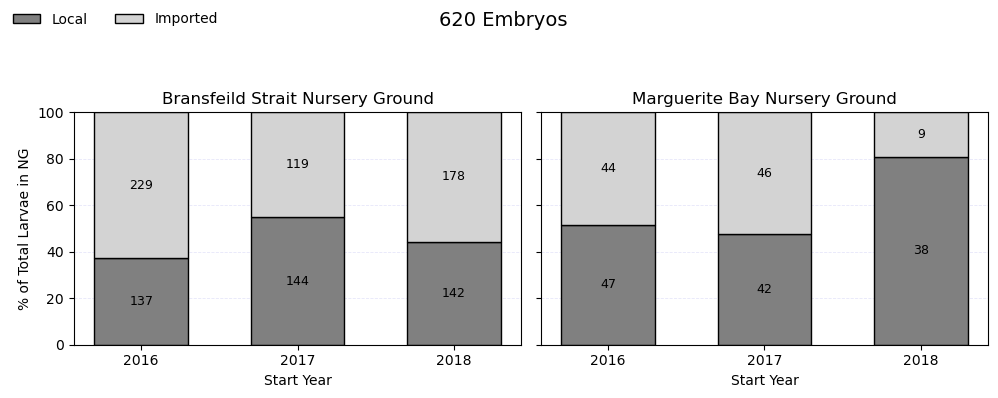

In [57]:
# Filter and compute % imported
df_plot = summary_combined[
    (summary_combined['hypothesis'] == 'h_dvm') &
    (summary_combined['nursery'].isin(['BS', 'MB2']))
].copy()

df_plot['percent_imported'] = (df_plot['spawn_external'] / df_plot['total_larvae'] * 100).round(1)

# Settings
nurseries = ['BS', 'MB2']
years = [2016, 2017, 2018]
bar_width = 0.6
fig, axes = plt.subplots(1, len(nurseries), figsize=(10, 4), sharey=True)

for ax, nursery in zip(axes, nurseries):
    df_n = df_plot[df_plot['nursery'] == nursery].sort_values('start_year')

    x = range(len(years))
    local = df_n['percent_inhouse'].values
    imported = df_n['percent_imported'].values
    local_counts = df_n['spawn_local'].values
    imported_counts = df_n['spawn_external'].values
    ax.set_axisbelow(True)
    # Stacked bars
    bars1 = ax.bar(x, local, bar_width,
                   label='Local', color='gray', edgecolor='black')
    bars2 = ax.bar(x, imported, bar_width,
                   bottom=local, label='Imported', color='lightgray', edgecolor='black')

    # Annotations for each section
    for i in range(len(x)):
        ax.text(x[i], local[i]/2, str(int(local_counts[i])),
                ha='center', va='center', fontsize=9, color='black')
        ax.text(x[i], local[i] + imported[i]/2, str(int(imported_counts[i])),
                ha='center', va='center', fontsize=9, color='black')

    # Axes formatting
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    ax.set_title(f"{nursery_info[nursery]['label']} Nursery Ground")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Start Year")
    ax.grid(axis='y', which='major', linestyle='--', linewidth=0.6, color='lavender')
    if ax == axes[0]:
        ax.set_ylabel("% of Total Larvae in NG")

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, frameon=False)

fig.suptitle("620 Embryos", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

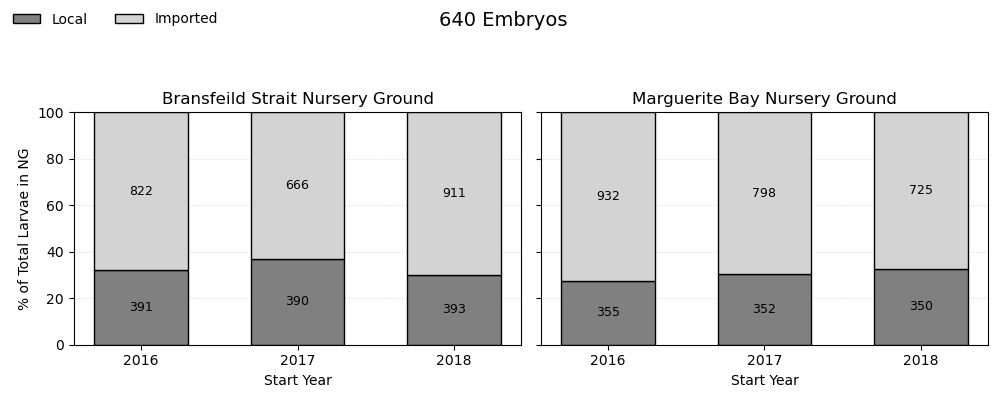

In [58]:

# Filter and compute % imported
df_plot = summary_combined[
    (summary_combined['hypothesis'] == 'h_size') &
    (summary_combined['nursery'].isin(['BS', 'MB2']))
].copy()

df_plot['percent_imported'] = (df_plot['spawn_external'] / df_plot['total_larvae'] * 100).round(1)

# Settings
nurseries = ['BS', 'MB2']
years = [2016, 2017, 2018]
bar_width = 0.6
fig, axes = plt.subplots(1, len(nurseries), figsize=(10, 4), sharey=True)

for ax, nursery in zip(axes, nurseries):
    df_n = df_plot[df_plot['nursery'] == nursery].sort_values('start_year')

    x = range(len(years))
    local = df_n['percent_inhouse'].values
    imported = df_n['percent_imported'].values
    local_counts = df_n['spawn_local'].values
    imported_counts = df_n['spawn_external'].values
    ax.set_axisbelow(True)
    # Stacked bars
    bars1 = ax.bar(x, local, bar_width,
                   label='Local', color='gray', edgecolor='black')
    bars2 = ax.bar(x, imported, bar_width,
                   bottom=local, label='Imported', color='lightgray', edgecolor='black')

    # Annotations for each section
    for i in range(len(x)):
        ax.text(x[i], local[i]/2, str(int(local_counts[i])),
                ha='center', va='center', fontsize=9, color='black')
        ax.text(x[i], local[i] + imported[i]/2, str(int(imported_counts[i])),
                ha='center', va='center', fontsize=9, color='black')

    # Axes formatting
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    ax.set_title(f"{nursery_info[nursery]['label']} Nursery Ground")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Start Year")
    ax.grid(axis='y', which='major', linestyle='--', linewidth=0.6, color='lavender')
    if ax == axes[0]:
        ax.set_ylabel("% of Total Larvae in NG")
# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, frameon=False)

fig.suptitle("640 Embryos", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import hypotheses, locations, extents

# --- File and Path Config ---
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/data/'
output_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/processed_data/'
fig_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/retention-plots'

presence_columns = ['BS', 'GERL', 'GP', 'MB2', 'outside']
critical_columns = ['larval_id', 'date', 'lon', 'lat', 'hypothesis', 'start_year', 'IDL_loc', 'stage']


# Load the unfiltered data
file = output_path + 'processed_trajectories_wpresence_unfiltered.csv'
processed_df = pd.read_csv(file)
print('Raw number of larvae:', processed_df.larval_id.nunique())

# Load the filtered data
filef = output_path + 'processed_trajectories_21dfilter.csv'
processed_dff = pd.read_csv(filef)
print('Raw number of larvae:', processed_dff.larval_id.nunique())

# Function to create the starting location DataFrame
def create_starting_location_df(df):
    t0_data = df[df['T'] == 0].copy()
    starting_locations = t0_data[critical_columns+presence_columns].copy()  # Use copy() to avoid SettingWithCopyWarning
    starting_locations.rename(columns={'date': 'release_date', 'lat': 'release_lat', 'lon': 'release_lon'}, inplace=True)
    return starting_locations

# Create the starting location DataFrame
starting_location_df = create_starting_location_df(processed_df)
# Create the starting location DataFrame
starting_location_dff = create_starting_location_df(processed_dff)


In [ ]:
# Extract Retention Data
def extract_retention_data(merged_df, hypotheses):
    """
    Extract retention times for each larva
    """
    merged = merged_df

    # Proceed as before
    records = []
    ordered_locations = sorted(locations.keys(), key=lambda x: location_order[x])

    for hypothesis in hypotheses:
        for location in ordered_locations:
            subset = merged[
                (merged['IDL_loc'] == location) &
                (merged['hypothesis'] == hypothesis)
            ]

            melted = subset.melt(
                id_vars=['hypothesis', 'start_year', 'IDL_loc', 'larval_id'],
                value_vars=presence_columns[:-1],
                var_name='Location',
                value_name='Retention_Days'
            )

            melted = melted[
                (melted['Location'] == location) &
                (melted['Retention_Days'] >= 0)
            ]

            melted['Season'] = melted['start_year'].astype(int).apply(lambda x: f"{x}–{x + 1}")
            records.append(melted)

    return pd.concat(records, ignore_index=True)

In [ ]:
#unfiltered
retention_df = extract_retention_data(grouped_df, starting_location_df, hypotheses=['h_dvm', 'h_size'])
retention_df

#21dfiltered
retention_dff = extract_retention_data(grouped_dff, starting_location_dff, hypotheses=['h_dvm', 'h_size'])
retention_dff

In [ ]:
# Define the summarization function again for this environment
def summarize_retention_by_subplot(retention_df, prefix='retention_stats'):
    """Generate summary stats per (hypothesis, IDL_loc) combination and return as dict of DataFrames."""

    all_summaries = {}

    # Get unique combinations
    for hypothesis in retention_df['hypothesis'].unique():
        for location in retention_df['IDL_loc'].unique():
            # Filter to this subplot's data
            subset = retention_df[
                (retention_df['hypothesis'] == hypothesis) &
                (retention_df['IDL_loc'] == location)
            ]

            if subset.empty:
                continue  # skip if no data for this combo

            # Compute summary stats grouped by start year and season
            summary = subset.groupby(['start_year', 'Season'])['Retention_Days'].describe().round(2).reset_index()

            # Store in dictionary
            all_summaries[(hypothesis, location)] = summary

    return all_summaries


# Combine all summary DataFrames into one tidy DataFrame with extra metadata columns
def create_retention_summary_table(summary_dict):
    records = []

    for (hypothesis, location), df in summary_dict.items():
        for _, row in df.iterrows():
            records.append({
                'Nursery': location,
                'Hypothesis': hypothesis,
                'Start Year': row['start_year'],
                'Season': row['Season'],
                'n': int(row['count']),
                'Mean': row['mean'],
                'SD': row['std'],
                'Median': row['50%'],
                'Q1': row['25%'],
                'Q3': row['75%']
            })

    return pd.DataFrame.from_records(records)

# Create a more human-readable version of the summary table
def create_retention_summary_compact(summary_dict):
    records = []

    for (hypothesis, location), df in summary_dict.items():
        for _, row in df.iterrows():
            mean_sd = f"{row['mean']:.1f} ± {row['std']:.1f}" if not pd.isna(row['std']) else f"{row['mean']:.1f}"
            iqr = f"{row['50%']:.1f} ({row['25%']:.1f}–{row['75%']:.1f})"
            records.append({
                'Nursery': location,
                'Hypothesis': hypothesis,
                'Start Year': row['start_year'],
                'Season': row['Season'],
                'n': int(row['count']),
                'Mean ± SD': mean_sd,
                'Median (IQR)': iqr
            })

    return pd.DataFrame.from_records(records)



In [ ]:

# Summarize Unfiltered
summary_dict = summarize_retention_by_subplot(retention_df)

# Generate the  Unfiltered summary table
summary_table_df = create_retention_summary_table(summary_dict)

# Generate the compact  Unfiltered summary table
summary_compact_df = create_retention_summary_compact(summary_dict)


# Summarize  21dfiltered
summary_dict_f = summarize_retention_by_subplot(retention_dff)

# Generate the 21dfiltered summary table
summary_table_dff = create_retention_summary_table(summary_dict_f)

# Generate the compact 21dfiltered summary table
summary_compact_dff = create_retention_summary_compact(summary_dict_f)

# Step 1: Rename for clarity
df_21d = summary_compact_dff.rename(columns={'n': 'n_21d'})
df_raw = summary_compact_df.rename(columns={'n': 'n_raw'})

# Step 2: Merge on identifying columns
merged = pd.merge(
    df_raw[['Nursery', 'Hypothesis', 'Start Year', 'n_raw']],
    df_21d[['Nursery', 'Hypothesis', 'Start Year', 'n_21d']],
    on=['Nursery', 'Hypothesis', 'Start Year'],
    how='left'
)

# Step 3: Fill NaNs (no match = 0 larvae met 21-day threshold)
merged['n_21d'] = merged['n_21d'].fillna(0).astype(int)

# Step 4: Calculate % that did NOT meet 21-day threshold
merged['% <21d'] = ((merged['n_raw'] - merged['n_21d']) / merged['n_raw'] * 100).round(1)

# Step 1: Rename columns
raw = summary_compact_df.rename(columns={
    'n': 'n_raw',
    'Mean ± SD': 'Mean ± SD (raw)',
    'Median (IQR)': 'Median (IQR) (raw)'
})

filtered = summary_compact_dff.rename(columns={
    'n': 'n_21d',
    'Mean ± SD': 'Mean ± SD (21d)',
    'Median (IQR)': 'Median (IQR) (21d)'
})

# Step 2: Merge on shared identifiers
merged = pd.merge(
    raw,
    filtered,
    on=['Nursery', 'Hypothesis', 'Start Year', 'Season'],
    how='left'  # keep all rows from raw, even if no 21d match
)

# Step 3: Fill missing values where appropriate
merged['n_21d'] = merged['n_21d'].fillna(0).astype(int)
merged['Mean ± SD (21d)'] = merged['Mean ± SD (21d)'].fillna("—")
merged['Median (IQR) (21d)'] = merged['Median (IQR) (21d)'].fillna("—")

# Step 4: Calculate % not meeting 21-day threshold
merged['% <21d'] = ((merged['n_raw'] - merged['n_21d']) / merged['n_raw'] * 100).round(1)

# Optional: reorder columns
final_cols = [
    'Nursery', 'Hypothesis', 'Start Year', 'Season',
    'n_raw', 'Mean ± SD (raw)', 'Median (IQR) (raw)',
    'n_21d', 'Mean ± SD (21d)', 'Median (IQR) (21d)',
    '% <21d'
]
summary_comparison_df = merged[final_cols]

# Tidy!
# Step 1: Drop 'Start Year'
summary_comparison_df = summary_comparison_df.drop(columns=['Start Year'])

# Step 2: Replace names in Nursery and Hypothesis
summary_comparison_df['Nursery'] = summary_comparison_df['Nursery'].replace({
    'MB2': 'MB',
    'GERL': 'GS'
})

summary_comparison_df['Hypothesis'] = summary_comparison_df['Hypothesis'].replace({
    'h_dvm': '620',
    'h_size': '640'
})

# Step 3: Rename 'Hypothesis' column
summary_comparison_df = summary_comparison_df.rename(columns={'Hypothesis': 'Init Emb Sz'})

# Optional: reorder columns if desired
ordered_cols = [
    'Nursery', 'Init Emb Sz', 'Season',
    'n_raw', 'Mean ± SD (raw)', 'Median (IQR) (raw)',
    'n_21d', 'Mean ± SD (21d)', 'Median (IQR) (21d)',
    '% <21d'
]
summary_comparison_df = summary_comparison_df[ordered_cols]